## Before Starting (If you haven't done it already)
Go to https://aistudio.google.com/app/apikey copy generative language client free tier API key

After you did that click the key icon at the left sidebar add your API key with GOOGLE_API_KEY as name and your API key as the value and enable notebook access

## Setup

### Install dependencies

In [2]:
%pip install -qU 'google-genai>=1.0.0'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.6/222.6 kB 18.0 MB/s eta 0:00:00


### Set up your API key

To run the following cell, your API key must be stored it in a Colab Secret named `GOOGLE_API_KEY`. If you don't already have an API key, or you're not sure how to create a Colab Secret, see the [Authentication](../quickstarts/Authentication.ipynb) quickstart for an example.

In [3]:
from google import genai
from google.colab import userdata
from google.genai import types

GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")
client = genai.Client(api_key=GOOGLE_API_KEY)

### Choose a model

Different models have different ups and downs.

In [4]:
MODEL_ID="gemini-2.5-flash" # @param ["gemini-2.5-flash", "gemini-2.5-pro", "gemini-2.0-flash", "gemini-2.5-flash-lite-preview-06-17", ""] {"allow-input":true, isTemplate: true}

## How do i *talk* to an LLM?

The first method is straightforward: your speech is recorded and then converted into text by a transcription system. In this setup, you are still technically communicating with the model through text, but you don’t have to type anything yourself. Instead, your spoken words are captured by a microphone, processed by a speech-to-text engine, and then the resulting transcription is sent to the model. This approach essentially replaces manual typing with automatic text generation from your voice, allowing for hands-free interaction while keeping the underlying communication format the same—text messages between you and the model.

In [5]:
URL = "https://storage.googleapis.com/generativeai-downloads/data/State_of_the_Union_Address_30_January_1961.mp3"

In [6]:
!wget -q $URL -O sample.mp3

In [7]:
your_audio_file = client.files.upload(file='sample.mp3')

In [8]:
response = client.models.generate_content(
  model=MODEL_ID,
  contents=[
    'Provide an exact transcript of the speech between the timestamps 9:30 to 10:00.',
    your_audio_file,
  ]
)

print(response.text)

9:30 to 10:00.00:

9:30 The gap between the dollars we spend or invest abroad and the dollars returned to us has substantially widened. This overall deficit in our balance of payments increased by nearly $11 billion in the last three years, and holders of dollars abroad converted them to gold in such a quantity as to cause a total outflow of nearly $5 billion of gold from our reserves. The 1959 deficit


You can do the same with your own voice recording


In [15]:
from IPython.display import Javascript, display, Audio
from google.colab import output
from base64 import b64decode

UI_JS = """
async function recordWithUI() {
  const div = document.createElement('div');
  const startBtn = Object.assign(document.createElement('button'), {textContent: 'Start'});
  const stopBtn  = Object.assign(document.createElement('button'), {textContent: 'Stop', disabled: true});
  div.append(startBtn, stopBtn);
  document.body.append(div);

  const stream = await navigator.mediaDevices.getUserMedia({audio:true});
  const rec = new MediaRecorder(stream, {mimeType: 'audio/webm;codecs=opus'});
  let chunks = [];

  startBtn.onclick = () => { chunks = []; rec.start(); startBtn.disabled = true; stopBtn.disabled = false; };
  const done = new Promise(resolve => {
    stopBtn.onclick = () => { rec.stop(); stopBtn.disabled = true; };
    rec.ondataavailable = e => { if (e.data.size) chunks.push(e.data); };
    rec.onstop = async () => {
      stream.getTracks().forEach(t => t.stop());
      div.remove();
      const blob = new Blob(chunks, {type: 'audio/webm;codecs=opus'});
      const reader = new FileReader();
      reader.onloadend = () => resolve(reader.result);
      reader.readAsDataURL(blob);
    };
  });

  startBtn.click();  // auto-start; you can remove this if you want manual start
  return await done;
}
"""
display(Javascript(UI_JS))
b64 = output.eval_js("recordWithUI()")
audio_bytes = b64decode(b64.split(",")[1])
with open("clip.webm", "wb") as f: f.write(audio_bytes)
!ffmpeg -y -i clip.webm -ac 1 -ar 16000 clip.wav -loglevel error
display(Audio("clip.wav"))
print("Saved clip.webm and clip.wav")


<IPython.core.display.Javascript object>

Saved clip.webm and clip.wav


In [16]:
!ffmpeg -y -i clip.webm -ac 1 -ar 16000 -c:a libmp3lame -q:a 5 clip.mp3 -loglevel error
display(Audio("clip.mp3"))
print("Saved clip.mp3")
your_audio_file = client.files.upload(file='clip.mp3')
response = client.models.generate_content(
  model=MODEL_ID,
  contents=[
    'Bu ses kaydının isabetli bir transkirpitini çıkar. Transkript dışında hiçbir şey olmasın',
    your_audio_file,
  ]
)

print(response.text)
message = response.text

Saved clip.mp3
Lost'un sonu nasıldı ya?


Then i can send my transcribed clip for the model to answer

In [17]:
response = client.models.generate_content(
  model=MODEL_ID,
  contents=[
    message
  ]
)

print(response.text)

Lost dizisinin sonu, izleyiciler arasında en çok tartışılan ve yanlış anlaşılan konulardan biridir. İşte özetle ne olduğu:

**Öncelikle en büyük yanlış anlaşılmayı düzeltelim:** Hayır, dizideki karakterler başından beri ölü değildi! Uçak kazası ve adada yaşadıkları her şey, Dharma Girişimi, Diğerleri, Jacob, Siyahlı Adam, zamanda yolculuklar vb. hepsi GERÇEKTİ ve yaşandı.

**Peki o "flash-sideways" (paralel evren/alternatif gerçeklik) sahneleri neydi?**

Dizinin son sezonunda gördüğümüz, Oceanic 815 uçağının hiç düşmediği ve karakterlerin normal hayatlarını sürdürdüğü "flash-sideways" sahneleri, aslında karakterlerin **ölümlerinden sonra buluşmak için yarattıkları bir ara duraktı.**

*   Bu "ara durak", onların birbirlerini bulabildikleri, adada yaşadıkları hayatı ve birbirleriyle olan bağlarını hatırlayabildikleri, bu sayede "ilerleyebildikleri" (öbür dünyaya geçebildikleri) bir yerdi.
*   Her karakter, adada geçirdiği dönemde kendisi için en önemli olan kişiyle temas kurarak "uyanış"

This process can be executed with relatively low latency, especially when using faster models. In fact, the primary bottleneck is not the processing or generation step itself, but rather the response time of the speech-to-text (STT) model. The time it takes to accurately transcribe audio into text often dominates the overall latency, meaning that even with highly optimized downstream models, the end-to-end speed will still be constrained by the STT system’s performance. Which can be heavily optimized for seamless interaction.

The nuance is though this is not the only way in fact LLM can take general sound as input not only speech that should be converted to text. When the input is a non-speech audio signal (music, environmental noise, animal sounds, machinery, etc.), the model does not necessarily need to “transcribe” it into words. Instead, the audio is passed through an audio encoder such as a convolutional front-end, a wav2vec-like transformer, or a spectrogram-based vision transformer which transforms the waveform into high-dimensional embeddings. These embeddings capture not just linguistic content (if present) but also timbre, pitch, rhythm, texture, and temporal patterns.

In [44]:
url="https://www.youtube.com/shorts/NsMKvVdEPkw"
prompt="Analyze the emotion that emits from the sound of the video and tell me why do you think that"
response = client.models.generate_content(
    model=MODEL_ID,
    contents=types.Content(
        parts=[
            types.Part(text=prompt),
            types.Part(
                file_data=types.FileData(file_uri=url)
            )
        ]
    )
)
display(Markdown(response.text))

The emotion that primarily emits from the sound of the video is **insistence** or **demanding attention/something specific**.

Here's why:

1.  **The Nature of the Meow:** The meows are not soft, gentle purrs, nor are they short, chirpy greetings. They are relatively long, drawn-out, and have a noticeable volume and resonance. This kind of vocalization in cats often signifies a request or a demand.
2.  **Repetition/Emphasis:** There are two distinct meows, and the second one comes quickly after the first, reinforcing the message. This repetition indicates that the cat is persistent in conveying its need or desire.
3.  **Absence of Other Sounds:** There's no purring (indicating contentment), no hissing or growling (indicating aggression or fear), nor any high-pitched distress calls. This leaves the more common "I want something" category.
4.  **Typical Cat Communication:** This type of vocalization is very common when cats want food, playtime, petting, to be let into or out of a room, or simply to get their human's undivided attention. The visual of the cat looking directly at the camera with wide eyes further supports the idea of it trying to communicate directly with the viewer/owner.

## How to make the LLM *see*

When an image or video frame is provided, it is first processed by a vision encoder such as a convolutional neural network (CNN) backbone or a Vision Transformer (ViT) which transforms the raw pixel matrix into a sequence of dense feature vectors (embeddings) in a high-dimensional latent space. Text input, whether typed directly or transcribed from speech via an automatic speech recognition (ASR) model, is tokenized and embedded into the same or a compatible vector space. In a multimodal architecture such as Gemini, these visual and textual embeddings are projected into a shared representation space and passed through a transformer-based fusion module that models cross-modal attention, enabling the network to align semantic elements in the image with linguistic tokens in the query. The fused contextual representation is then fed into the language generation head, which autoregressively predicts the output token sequence conditioned jointly on visual and textual context, producing an answer that integrates information from both modalities.

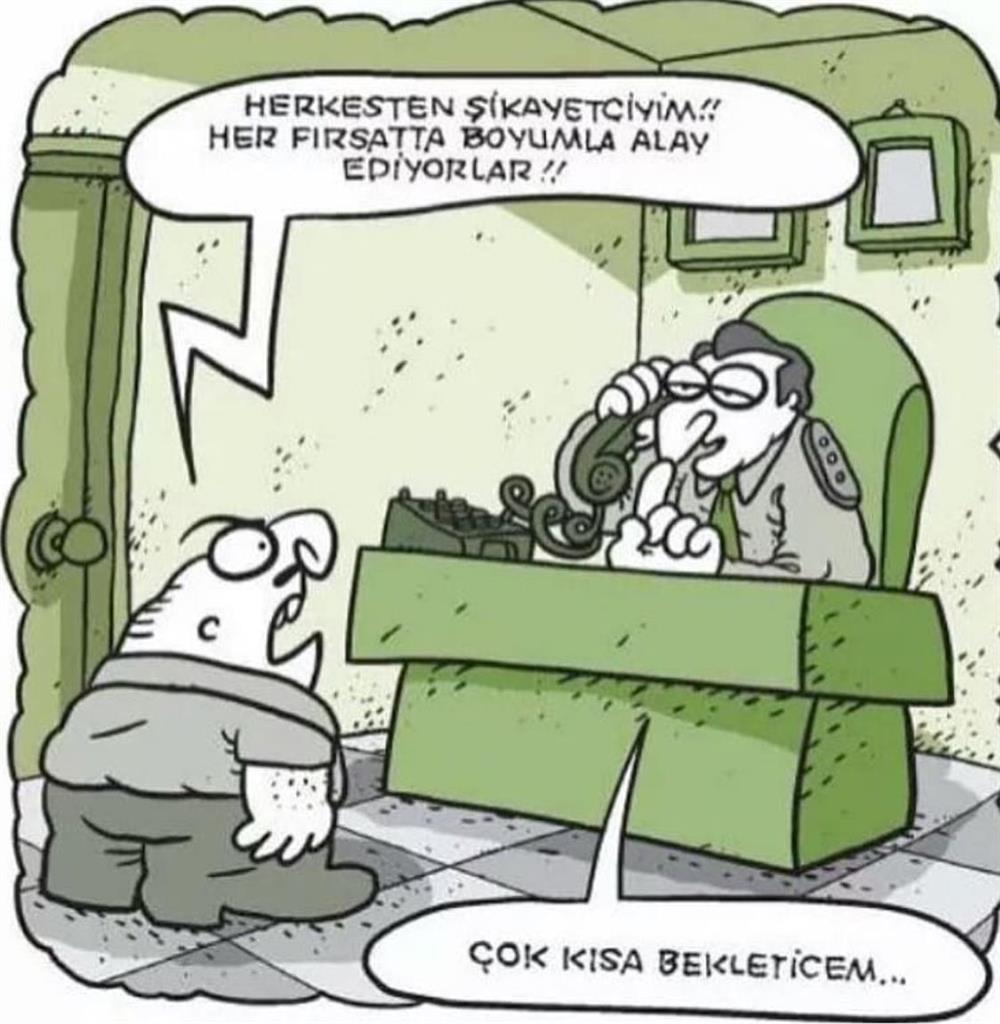

Since the model can process still images and “see” their content, then you might think it is also possible to provide multiple still images in a single request, allowing it to interpret and connect visual information across them... and you'd be exactly right! In such cases, each image is independently encoded into a sequence of feature vectors by the vision encoder, and these sequences are concatenated or otherwise combined before being projected into the shared multimodal representation space. The transformer fusion module can then attend across embeddings from different images as well as the accompanying text input, enabling the model to reason about temporal progression, spatial relationships, or conceptual links between scenes. This capability allows it to synthesize a coherent understanding of multiple visuals, identify patterns or changes, and generate responses that integrate information across the entire set of provided images.

In [25]:
from google import genai
from IPython.display import Markdown, display
import requests, tempfile

url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT6_HETIpesfLE4zBOrjNrk5heNa_G1EidS1Q&s"

with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as f:
    f.write(requests.get(url, timeout=15).content)
    tmp_path = f.name

myfile = client.files.upload(file=tmp_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=["Bu karikatürü analiz et, neden komik?", myfile],
)
display(Markdown(response.text))


Bu karikatürün komik olmasının temel nedeni **ironi** ve **kelime oyunu (double entendre)** kullanımıdır.

Analiz edelim:

1.  **Durum:** Karikatürde, boyunun kısalığı nedeniyle sürekli alay edildiğinden şikayet eden, oldukça kısa boylu bir adam görüyoruz. Bu, onun için hassas ve rahatsız edici bir konudur. Bu durumu polise veya şikayet masasına bildirmek için gelmiştir.

2.  **Şikayetçi Adamın Diyaloğu:** "HERKESTEN ŞİKAYETÇİYİM!! HER FIRSATTA BOYUMLA ALAY EDİYORLAR!!" Bu ifade, adamın ne kadar çaresiz ve bu konudan bunalmış olduğunu gösteriyor.

3.  **Memurun Diyaloğu:** Memur telefonda konuşurken, şikayetçi adama dönerek değil, telefondaki kişiye hitaben "ÇOK KISA BEKLETİCEM..." diyor.

4.  **Komik Olan Kısım (Punchline):** Buradaki espri, memurun kullandığı "ÇOK KISA BEKLETİCEM" ifadesidir.
    *   **Memurun Kastettiği Anlam:** Memur, telefondaki kişiyi "çok kısa bir süre" (yani az bir zaman) bekleteceğini söylemektedir.
    *   **Şikayetçi Adamın Anladığı/Algıladığı Anlam:** Şikayetçi adam, kendi boyuyla ilgili hassasiyeti nedeniyle, "kısa" kelimesini direkt olarak "kısa boylu" anlamıyla bağdaştırır. Yani, kendi boyuna bir gönderme, bir alay olarak algılar.

**Neden Komik?**

*   **İroni:** Adam, boyuyla alay edildiği için şikayetçi olmaya gelmişken, şikayetini dinleyecek olan (ya da orada çalışan) kişi farkında olmadan tam da onun hassas olduğu "kısa" kelimesini kullanır. Bu durum, trajikomik bir ironi yaratır. Adamın tam da kaçtığı durum, beklenmedik bir şekilde karşısına çıkar.
*   **Kelime Oyunu (Çift Anlamlılık):** "Kısa" kelimesinin hem "süre olarak az" hem de "boy olarak küçük" anlamlarına gelmesi, espriyi güçlendirir. Memur bir anlamı kastediyor, ama adam diğer anlamla vuruluyor.
*   **Karakterin Hassasiyeti:** Adamın aşırı hassasiyeti, memurun masum cümlesini bile kişisel bir saldırı olarak algılamasına yol açıyor. Bu abartılı algı da komiktir.
*   **Seyircinin Durumu Anlaması:** Biz seyirci olarak hem memurun ne kastettiğini hem de şikayetçi adamın nasıl bir yanılgıya düştüğünü anlarız. Bu bilgi üstünlüğü ve yanlış anlaşılmanın ironisi bizi güldürür.

Kısacası, karikatür, bir kişinin en hassas noktasının, o kişi hakkında hiçbir kötü niyeti olmayan bir başka kişi tarafından farkında olmadan tekrar gündeme getirilmesiyle ortaya çıkan absürt ve ironik durumu ustaca kullanır.

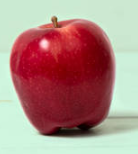

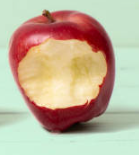

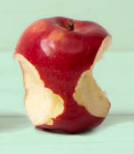

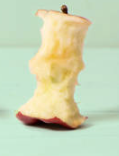

In [27]:
img1="https://raw.githubusercontent.com/UYildiz12/llm-robotics-intro-psych/main/public/1.PNG"
img2="https://raw.githubusercontent.com/UYildiz12/llm-robotics-intro-psych/main/public/2.PNG"
img3="https://raw.githubusercontent.com/UYildiz12/llm-robotics-intro-psych/main/public/3.PNG"
img4="https://raw.githubusercontent.com/UYildiz12/llm-robotics-intro-psych/main/public/4.PNG"


In [29]:
img_urls = [img1, img2, img3, img4]

uploaded_files = []
for url in img_urls:
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        f.write(r.content)
        uploaded_files.append(client.files.upload(file=f.name))

prompt = """
What happened here respond in 4 words
"""

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[prompt, *uploaded_files],
)

display(Markdown(response.text))

The apple was eaten.

In [43]:
new_prompt = "Why do you say that?"

response2 = client.models.generate_content(
    model=MODEL_ID,
    contents=[*uploaded_files, response, new_prompt],
)

display(Markdown(response2.text))

I say that because the sequence of images clearly demonstrates the process of an apple being consumed:

1.  **Image 1:** Shows a whole, untouched apple.
2.  **Image 2:** A significant portion of the apple has been bitten off, revealing the lighter flesh underneath.
3.  **Image 3:** More of the apple is missing, with multiple bite marks visible.
4.  **Image 4:** Only the core and a small amount of flesh remain, indicating that the majority of the apple has been eaten.

The progressive reduction in the apple's size and the presence of bite marks are direct evidence that it was eaten.

Now lets combine both to get a detailed analysis

In [ ]:
youtube_url = "https://www.youtube.com/watch?v=Tn9FCTwx2kQ&list=RDTn9FCTwx2kQ&start_radio=1"

prompt = """
    Analyze the following YouTube video content. Explain to me exactly what is happening in the video first, then give me the full lyrics of the song being played

"""

response = client.models.generate_content(
    model=MODEL_ID,
    contents=types.Content(
        parts=[
            types.Part(text=prompt),
            types.Part(
                file_data=types.FileData(file_uri=youtube_url)
            )
        ]
    )
)
display(Markdown(response.text))

For a robot, the ability to see through its camera is a major upgrade because it allows operation with real-time awareness of its surroundings. Vision lets the robot recognize objects, detect obstacles, interpret gestures, read signs, and adapt its behavior dynamically. When combined with other modalities such as audio, interactions become more natural and autonomous.

The trade-off is that more modalities mean more preprocessing and embedding generation, which increases computational load and latency. In real-time applications such as navigation, collaboration, or safety critical tasks, even small delays can be unacceptable. In our next notebook we will see how the to make the model speak to us using gemini inhouse TTS. And then bring it all together.